In [ ]:
import pandas as pd
import numpy as np
import random
import seaborn as sns

import math

from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix
from numpy.random import randn, seed

In [ ]:
data = pd.read_csv('healthcare-dataset-stroke-data.csv')

In [ ]:
data.drop(columns='id', inplace=True)
data

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [ ]:
data['gender'].replace({'Male':0, 'Female': 1,'Other':2}, inplace=True)
data['ever_married'].value_counts()

Yes    3353
No     1757
Name: ever_married, dtype: int64

In [ ]:
data.duplicated().sum()

0

In [ ]:
data.stroke.value_counts(normalize=True)

0    0.951272
1    0.048728
Name: stroke, dtype: float64

In [ ]:
round(data.age.sort_values())[:100]

3295    0.0
1614    0.0
3618    0.0
4021    0.0
3968    0.0
       ... 
1101    2.0
4006    2.0
1137    2.0
1758    2.0
913     2.0
Name: age, Length: 100, dtype: float64

In [ ]:
data[data.stroke == 1]['age'].nsmallest(10)

162     1.32
245    14.00
182    32.00
118    38.00
133    38.00
49     39.00
210    39.00
228    39.00
31     42.00
79     43.00
Name: age, dtype: float64

In [ ]:
data = data[data['age'] >= 14]

In [ ]:
data[data['gender'] == 2]
data.drop(index=3116, inplace=True)

/usr/local/lib/python3.7/dist-packages/pandas/core/frame.py:4174: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  errors=errors,


In [ ]:
data[data['gender'] == 2]

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4464 entries, 0 to 5109
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4464 non-null   int64  
 1   age                4464 non-null   float64
 2   hypertension       4464 non-null   int64  
 3   heart_disease      4464 non-null   int64  
 4   ever_married       4464 non-null   object 
 5   work_type          4464 non-null   object 
 6   Residence_type     4464 non-null   object 
 7   avg_glucose_level  4464 non-null   float64
 8   bmi                4279 non-null   float64
 9   smoking_status     4464 non-null   object 
 10  stroke             4464 non-null   int64  
dtypes: float64(3), int64(4), object(4)
memory usage: 418.5+ KB


In [ ]:
data.smoking_status.value_counts()

never smoked       1847
Unknown             959
formerly smoked     872
smokes              786
Name: smoking_status, dtype: int64

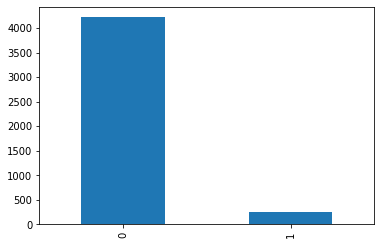

In [ ]:
data.stroke.value_counts().plot(kind = 'bar')

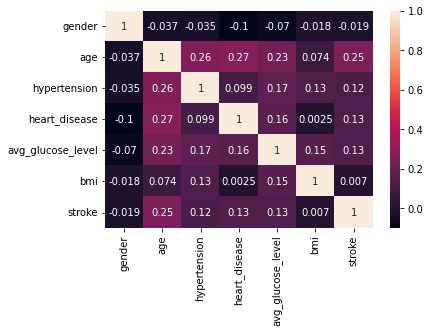

In [ ]:
sns.heatmap(data.corr(), annot=True)

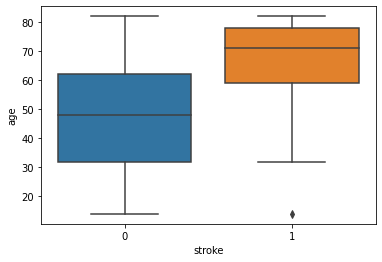

In [ ]:
sns.boxplot(data = data, x = 'stroke', y = 'age');

In [ ]:
data.head()

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,0,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,1,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,0,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,1,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


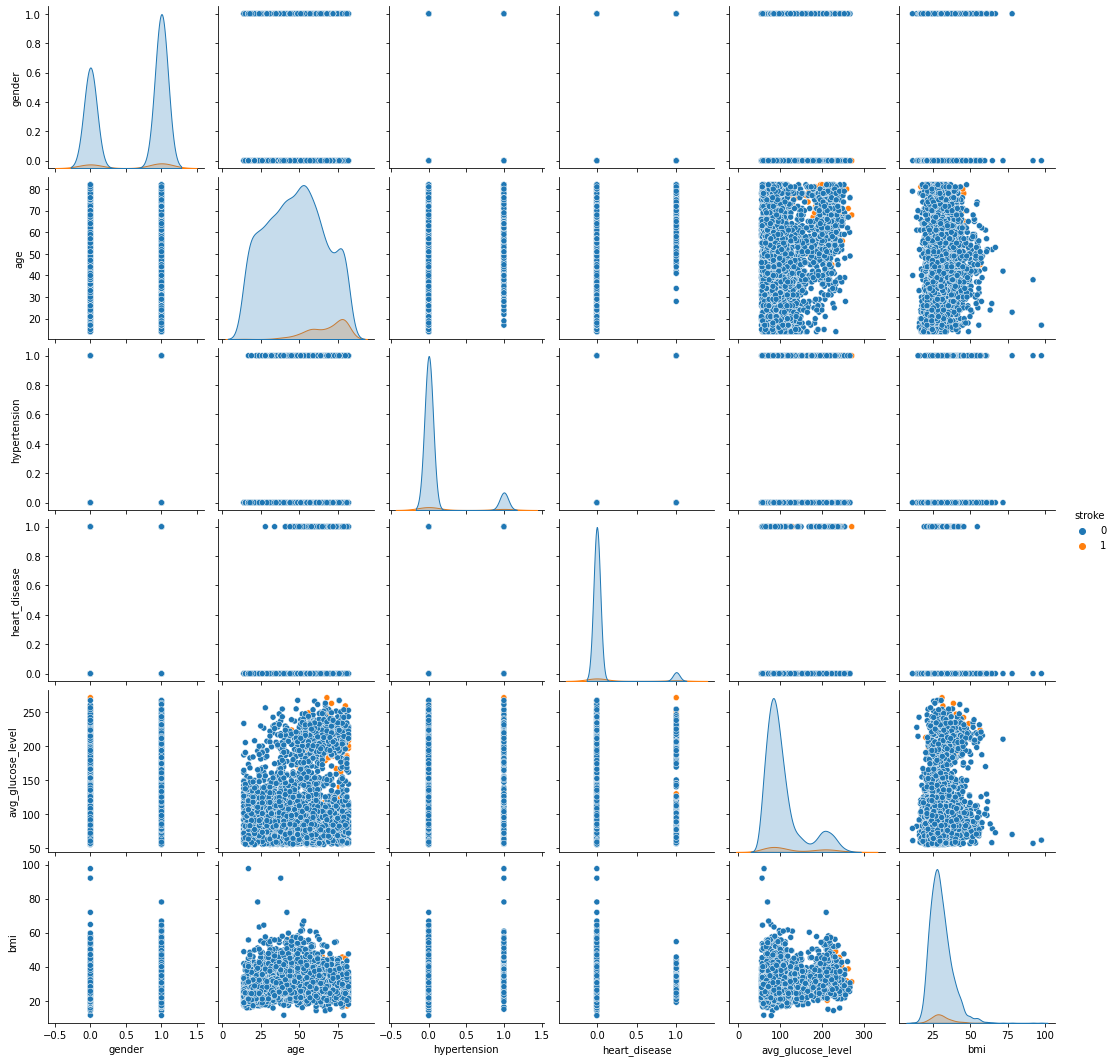

In [ ]:
sns.pairplot(data, hue = 'stroke')

In [ ]:
data_cat = data.select_dtypes(include='object').columns
data_cat

Index(['ever_married', 'work_type', 'Residence_type', 'smoking_status'], dtype='object')

In [ ]:
data = pd.get_dummies(data, drop_first=True)
data

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,67.0,0,1,228.69,36.6,1,1,0,1,0,0,1,1,0,0
1,1,61.0,0,0,202.21,NaN,1,1,0,0,1,0,0,0,1,0
2,0,80.0,0,1,105.92,32.5,1,1,0,1,0,0,0,0,1,0
3,1,49.0,0,0,171.23,34.4,1,1,0,1,0,0,1,0,0,1
4,1,79.0,1,0,174.12,24.0,1,1,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,80.0,1,0,83.75,NaN,0,1,0,1,0,0,1,0,1,0
5106,1,81.0,0,0,125.20,40.0,0,1,0,0,1,0,1,0,1,0
5107,1,35.0,0,0,82.99,30.6,0,1,0,0,1,0,0,0,1,0
5108,0,51.0,0,0,166.29,25.6,0,1,0,1,0,0,0,1,0,0


In [ ]:
data.bmi.isnull().sum()

185

In [ ]:
X = data.drop('stroke', axis = 1)
y = data['stroke']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state=42)

In [ ]:
import missingno as msno

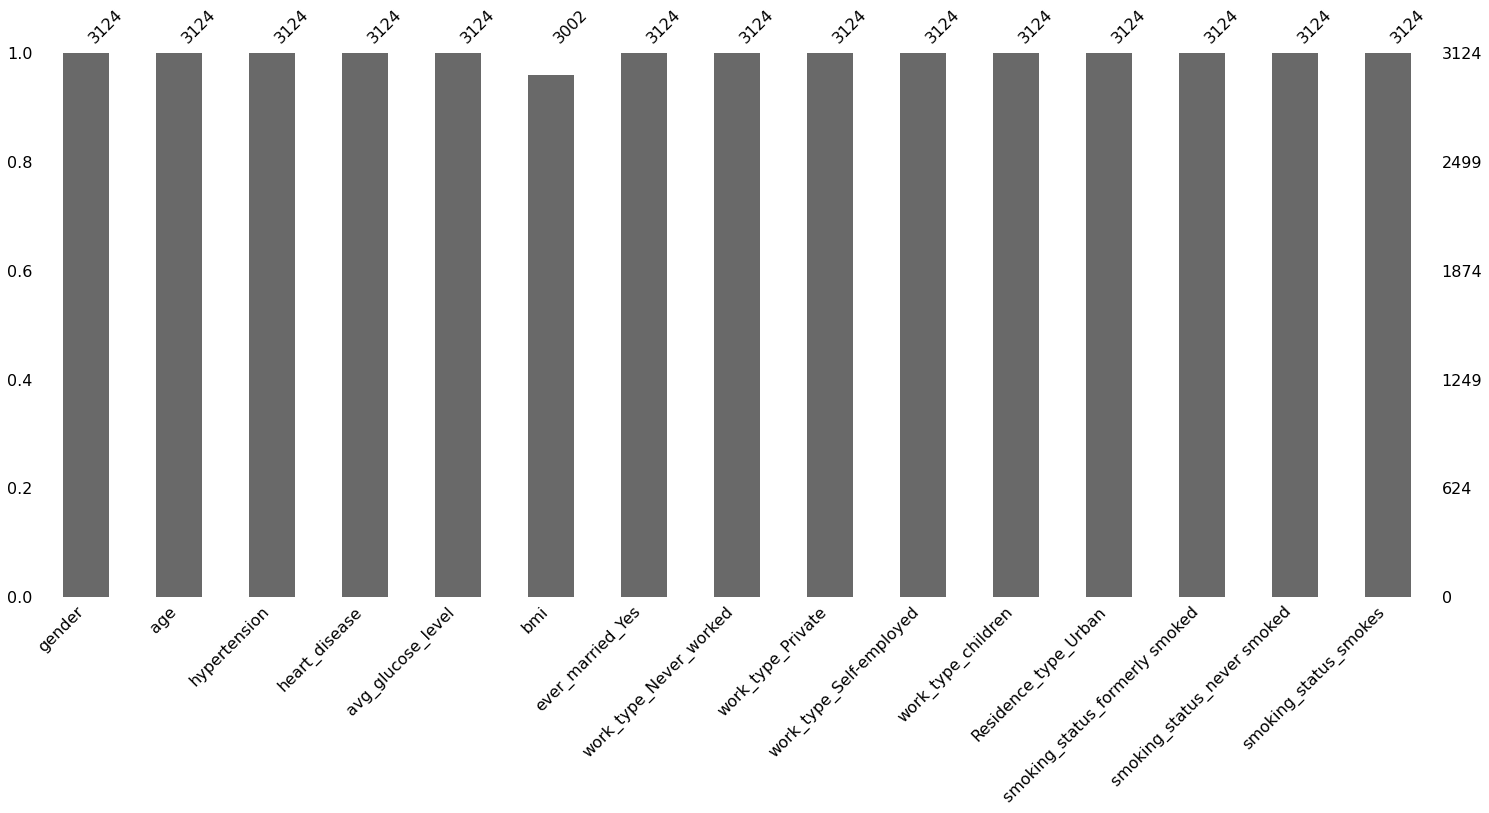

In [ ]:
msno.bar(X_train)

In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer = SimpleImputer(missing_values = np.nan, strategy='median')

X_train['bmi'] = imputer.fit_transform(X_train['bmi'].values.reshape(-1,1))[:,0]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until


In [ ]:
X_test['bmi'] = imputer.fit_transform(X_test['bmi'].values.reshape(-1,1))[:,0]

/usr/local/lib/python3.7/dist-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


In [ ]:
print(X_test.isnull().sum())

gender                            0
age                               0
hypertension                      0
heart_disease                     0
avg_glucose_level                 0
bmi                               0
ever_married_Yes                  0
work_type_Never_worked            0
work_type_Private                 0
work_type_Self-employed           0
work_type_children                0
Residence_type_Urban              0
smoking_status_formerly smoked    0
smoking_status_never smoked       0
smoking_status_smokes             0
dtype: int64


In [ ]:
X_train

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1073,1,38.0,0,0,162.30,23.6,1,0,1,0,0,1,0,1,0
2665,1,25.0,0,0,103.15,21.0,0,0,0,0,0,0,0,0,1
4362,1,51.0,1,0,69.94,33.3,1,0,0,0,0,1,0,0,1
2129,0,50.0,1,0,220.36,40.9,1,0,1,0,0,0,1,0,0
1456,0,62.0,0,0,78.99,45.5,1,0,0,1,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5064,0,70.0,0,0,193.88,24.3,1,0,0,1,0,0,0,0,0
498,1,15.0,0,0,114.53,29.1,0,0,0,0,1,0,0,0,0
3510,1,15.0,0,0,190.89,22.0,0,0,0,0,1,1,0,1,0
4310,1,45.0,0,0,68.66,25.3,1,0,0,0,0,0,0,1,0


In [ ]:
X_test

,gender,age,hypertension,heart_disease,avg_glucose_level,bmi,ever_married_Yes,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
303,0,66.0,0,0,242.30,35.3,1,0,1,0,0,0,0,0,1
1065,0,67.0,0,0,67.79,26.0,1,0,0,0,0,1,1,0,0
2307,0,49.0,0,0,220.47,36.4,1,0,0,1,0,0,0,0,1
644,1,43.0,0,0,98.09,17.3,1,0,0,1,0,1,0,1,0
3891,0,77.0,0,0,57.60,32.2,1,0,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3284,1,26.0,0,0,69.77,23.2,0,0,1,0,0,0,0,1,0
1201,0,46.0,0,0,85.35,32.1,1,0,1,0,0,1,0,0,1
511,1,51.0,0,0,82.93,29.7,1,0,1,0,0,0,0,0,1
790,1,24.0,0,0,97.92,23.1,1,0,1,0,0,0,0,1,0


In [ ]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**fit_transform**: +)sử dụng trên tập training. Ở đây, model được chúng ta xây dựng sẽ học từ giá trị trung bình và phương sai của các feature trong tập training.
+) fit ở đây là tính các giá trị trung bình và phương sai của từng feature trong data. **transform** dùng để biến đổi các giá trị đấy theo công thức scale

**transform**: sử dụng giá trị trung bình và phương sai đã được tính sẵn ở tập training. vì vậy các tham số được học bởi model sử dụng ở tập training giúp chúng ta transform test data


In [ ]:
len(X_train_scaled[0])

15

In [ ]:
X_test_scaled[0]

array([0.        , 0.76470588, 0.        , 0.        , 0.88026712,
       0.27809965, 1.        , 0.        , 1.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 1.        ])

In [ ]:
class NeuralNetwork:
  def __init__(self, n_input, n_output, epsilon_init = 0.12):
    self.epsilon_init = epsilon_init
    self.n_input = n_input
    self.n_output = n_output
    self.n_hidden = (n_input+n_output)//2
    self.theta1 = self.randInitializeWeights(n_input, self.n_hidden)
    self.theta2 = self.randInitializeWeights(self.n_hidden, n_output)

  def randInitializeWeights(self, n_in, n_out):
    seed(2)
    W = randn(n_out, n_in + 1) * 2 * self.epsilon_init - self.epsilon_init

    return W

  def sigmoid(self, z):
    return 1.0/(1.0+np.exp(-z))

  def sigmoidGradient(self, z):
    return self.sigmoid(z)*(1-self.sigmoid(z))

  def nnCostFunction(self, X, y, lamda):
    J = 0
    Theta1_grad = np.zeros(self.theta1.shape)
    Theta2_grad = np.zeros(self.theta2.shape)
    m = X.shape[0]

    A1 = np.hstack((np.ones((m, 1)), X))
    Z2 = np.dot(A1,self.theta1.transpose())
    A2 = np.hstack((np.ones((Z2.shape[0],1)), self.sigmoid(Z2)))
    Z3 = np.dot(A2,self.theta2.transpose())
    A3 = self.sigmoid(Z3)

    regular = np.sum(np.power(self.theta1[:,1:],2)) + np.sum(np.power(self.theta2[:,1:],2))
    y = np.array(y).reshape(-1,1)
    
    J = (1/m)*(np.sum(-y*np.log(A3),1) - np.sum((1-y)*np.log(1-A3),1))

    J = J + regular*(lamda/(2*m))

    sigma3 = A3 - y
    sigma2 = (np.dot(sigma3, self.theta2) * self.sigmoidGradient(np.hstack((np.ones((Z2.shape[0],1)), Z2))))[:,1:]

    delta_1 = np.dot(sigma2.transpose(), A1)
    delta_2 = np.dot(sigma3.transpose(), A2)

    Theta1_grad = delta_1/m + (lamda/m)*np.hstack((np.zeros((self.theta1.shape[0],1)), self.theta1[:,1:]))
    Theta2_grad = delta_2/m + (lamda/m)*np.hstack((np.zeros((self.theta2.shape[0],1)), self.theta2[:,1:]))

    return J, Theta1_grad, Theta2_grad 

  def update_theta(self, grad1, grad2, alpha = 0.01):
    self.theta1 = self.theta1 - alpha*grad1
    self.theta2 = self.theta2 - alpha*grad2
  
  def gradient_checking(self):
    pass
    
  def forward_propagate(self, X):
    m = X.shape[0]
    A1 = np.hstack((np.ones((m, 1)), X))
    Z2 = np.dot(A1,self.theta1.transpose())
    A2 = np.hstack((np.ones((Z2.shape[0],1)), self.sigmoid(Z2)))
    Z3 = np.dot(A2,self.theta2.transpose())
    A3 = self.sigmoid(Z3)
    return A3
    
net = NeuralNetwork(15,1)

In [ ]:
print(net.theta1)
print(net.theta2)

[[-2.20021883e-01 -1.33504039e-01 -6.32687063e-01  2.73664994e-01
  -5.50424540e-01 -3.22019368e-01  6.91540118e-04 -4.18869141e-01
  -3.73908533e-01 -3.38161828e-01  1.23489707e-02  4.30129923e-01
  -1.10030546e-01 -3.88302107e-01  9.37399694e-03 -2.63078328e-01]
 [-1.24591319e-01  1.62000293e-01 -2.99489028e-01 -1.17833940e-01
  -3.30745894e-01 -1.57544201e-01 -5.84230915e-02 -3.57306972e-01
  -2.01317272e-01 -1.76684167e-01 -2.73037203e-01 -4.05026949e-01
  -4.61092135e-01 -1.56838847e-01 -1.84573670e-01  4.15528029e-01]
 [-7.04344218e-01 -9.29456388e-02 -3.10933112e-02  2.06312127e-01
   4.45729628e-04 -3.22611289e-01 -1.19997657e-01  1.01646173e-02
  -1.95241967e-01  6.50428171e-02 -5.68341757e-01  2.95484320e-01
   2.32242723e-01 -2.00562561e-01  2.67217871e-02 -1.08487058e-01]
 [-3.18992469e-01 -9.89495476e-02  1.20087813e-01 -2.11462204e-01
  -2.10160662e-01 -1.37872983e-01 -1.59608808e-02  1.86811015e-01
  -2.72323033e-01  2.01509824e-03 -6.81321585e-02 -5.66066973e-01
  -2.20

In [ ]:
net.theta2

array([[-0.22002188, -0.13350404, -0.63268706,  0.27366499, -0.55042454,
        -0.32201937,  0.00069154, -0.41886914, -0.37390853]])

In [ ]:
J, grad1, grad2 = net.nnCostFunction(X_train_scaled, y_train, 3)
net.update_theta(grad1, grad2)
print(net.theta1)
print(net.theta2)


[[-2.19971461e-01 -1.33472304e-01 -6.32660163e-01  2.73666694e-01
  -5.50418005e-01 -3.22004992e-01  7.02613310e-04 -4.18831455e-01
  -3.73904485e-01 -3.38126239e-01  1.23573032e-02  4.30126851e-01
  -1.10003635e-01 -3.88291441e-01  9.39720711e-03 -2.63067427e-01]
 [-1.24299390e-01  1.62183577e-01 -2.99360344e-01 -1.17811022e-01
  -3.30734196e-01 -1.57476326e-01 -5.83581955e-02 -3.57098807e-01
  -2.01313143e-01 -1.76485909e-01 -2.72990535e-01 -4.05018806e-01
  -4.60946250e-01 -1.56791435e-01 -1.84451984e-01  4.15585666e-01]
 [-7.04478229e-01 -9.30264124e-02 -3.11521741e-02  2.06298390e-01
   4.40766702e-04 -3.22638595e-01 -1.20026129e-01  1.00666792e-02
  -1.95241030e-01  6.49486339e-02 -5.68353469e-01  2.95479402e-01
   2.32166747e-01 -2.00581758e-01  2.66617681e-02 -1.08510176e-01]
 [-3.18691432e-01 -9.87637215e-02  1.20223798e-01 -2.11435547e-01
  -2.10147249e-01 -1.37801599e-01 -1.58939032e-02  1.87034299e-01
  -2.72318612e-01  2.21639783e-03 -6.80816213e-02 -5.66058290e-01
  -2.20

In [ ]:
check = net.forward_propagate(X_test_scaled)

In [ ]:
check[check < 0.5] = 0
check[check >= 0.5] = 1

In [ ]:
confusion = confusion_matrix(y_test, check)

In [ ]:
confusion

array([[1259,    0],
       [  81,    0]])

In [ ]:
print(classification_report(y_test, check))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1259
           1       0.00      0.00      0.00        81

    accuracy                           0.94      1340
   macro avg       0.47      0.50      0.48      1340
weighted avg       0.88      0.94      0.91      1340



/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py:1272: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
